# 📊 Level 2 — Task 3: K-Means Clustering
**Intern:** Amos Njama Mungai | **Company:** Codveda Technologies

**Dataset:** Churn Prediction Data

**Objectives:**
- Load a dataset and preprocess it (scaling)
- Apply K-Means clustering and determine optimal clusters using the elbow method
- Visualize clusters using 2D scatter plots
- Interpret the clustering results

**Tools:** Python, Scikit-learn, Matplotlib, Seaborn

## Step 1: Mount Google Drive

In [17]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted successfully')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully


## Step 2: Import Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## Step 3: Load the Dataset
> The Churn Prediction Data is inside a folder. This cell finds and loads it automatically.

In [19]:

churn_path = None
for root, dirs, files in os.walk('/content/drive/MyDrive/Data Set For Task'):
    for file in files:
        if 'churn' in file.lower() and file.endswith('.csv'):
            churn_path = os.path.join(root, file)
            print(f'✅ Found: {churn_path}')

if churn_path is None:
    print('❌ Churn file not found. Checking all CSV files available:')
    for root, dirs, files in os.walk('/content/drive/MyDrive/Data Set For Task'):
        for file in files:
            print(os.path.join(root, file))

✅ Found: /content/drive/MyDrive/Data Set For Task/Churn Prdiction Data/churn-bigml-20.csv
✅ Found: /content/drive/MyDrive/Data Set For Task/Churn Prdiction Data/churn-bigml-80.csv


In [20]:
df = pd.read_csv(churn_path)
print('✅ Dataset loaded successfully')
print(f'Shape: {df.shape}')
df.head(10)

✅ Dataset loaded successfully
Shape: (2666, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
5,AL,118,510,Yes,No,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,False
6,MA,121,510,No,Yes,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,False
7,MO,147,415,Yes,No,0,157.0,79,26.69,103.1,94,8.76,211.8,96,9.53,7.1,6,1.92,0,False
8,WV,141,415,Yes,Yes,37,258.6,84,43.96,222.0,111,18.87,326.4,97,14.69,11.2,5,3.02,0,False
9,RI,74,415,No,No,0,187.7,127,31.91,163.4,148,13.89,196.0,94,8.82,9.1,5,2.46,0,False


## Step 4: Explore the Dataset

In [21]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge 

In [22]:
print('=== Statistical Summary ===')
df.describe().round(2)

=== Statistical Summary ===


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00
mean,100.62,437.44,8.02,179.48,100.31,30.51,200.39,100.02,17.03,201.17,100.11,9.05,10.24,4.47,2.76,1.56
std,39.56,42.52,13.61,54.21,19.99,9.22,50.95,20.16,4.33,50.78,19.42,2.29,2.79,2.46,0.75,1.31
min,1.00,408.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,43.70,33.00,1.97,0.00,0.00,0.00,0.00
25%,73.00,408.00,0.00,143.40,87.00,24.38,165.30,87.00,14.05,166.92,87.00,7.51,8.50,3.00,2.30,1.00
50%,100.00,415.00,0.00,179.95,101.00,30.59,200.90,100.00,17.08,201.15,100.00,9.05,10.20,4.00,2.75,1.00
75%,127.00,510.00,19.00,215.90,114.00,36.70,235.10,114.00,19.98,236.48,113.00,10.64,12.10,6.00,3.27,2.00
max,243.00,510.00,50.00,350.80,160.00,59.64,363.70,170.00,30.91,395.00,166.00,17.77,20.00,20.00,5.40,9.00


In [23]:
print('=== Missing Values ===')
print(df.isnull().sum())

=== Missing Values ===
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


## Step 5: Preprocess the Dataset

In [24]:
# Drop duplicates
df = df.drop_duplicates()

# Drop non-informative ID columns if any
id_cols = [c for c in df.columns if 'id' in c.lower() or 'customerid' in c.lower()]
if id_cols:
    df = df.drop(columns=id_cols)
    print(f'Dropped ID columns: {id_cols}')

# Fill missing values
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns: {categorical_cols}')
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(f'\n✅ Shape after preprocessing: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head()

Categorical columns: ['State', 'International plan', 'Voice mail plan']

✅ Shape after preprocessing: (2666, 20)
Missing values: 0


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,16,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,35,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,31,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,35,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,36,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## Step 6: Scale the Features

In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print(f'✅ Features scaled — Shape: {X_scaled.shape}')
print(f'Mean after scaling  : {X_scaled.mean(axis=0).round(4)}')
print(f'Std after scaling   : {X_scaled.std(axis=0).round(4)}')

✅ Features scaled — Shape: (2666, 20)
Mean after scaling  : [ 0. -0. -0. -0.  0. -0.  0.  0. -0. -0.  0.  0.  0. -0. -0. -0. -0.  0.
 -0.  0.]
Std after scaling   : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Step 7: Elbow Method — Find Optimal Number of Clusters

In [26]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(sil)
    print(f'K = {k}  →  Inertia: {kmeans.inertia_:,.1f}  |  Silhouette: {sil:.4f}')

K = 2  →  Inertia: 48,177.6  |  Silhouette: 0.1203
K = 3  →  Inertia: 45,360.9  |  Silhouette: 0.1244
K = 4  →  Inertia: 43,128.3  |  Silhouette: 0.0797
K = 5  →  Inertia: 41,576.6  |  Silhouette: 0.0718
K = 6  →  Inertia: 40,187.4  |  Silhouette: 0.0758
K = 7  →  Inertia: 39,181.9  |  Silhouette: 0.0687
K = 8  →  Inertia: 38,124.7  |  Silhouette: 0.0719
K = 9  →  Inertia: 37,161.5  |  Silhouette: 0.0750
K = 10  →  Inertia: 36,575.6  |  Silhouette: 0.0689


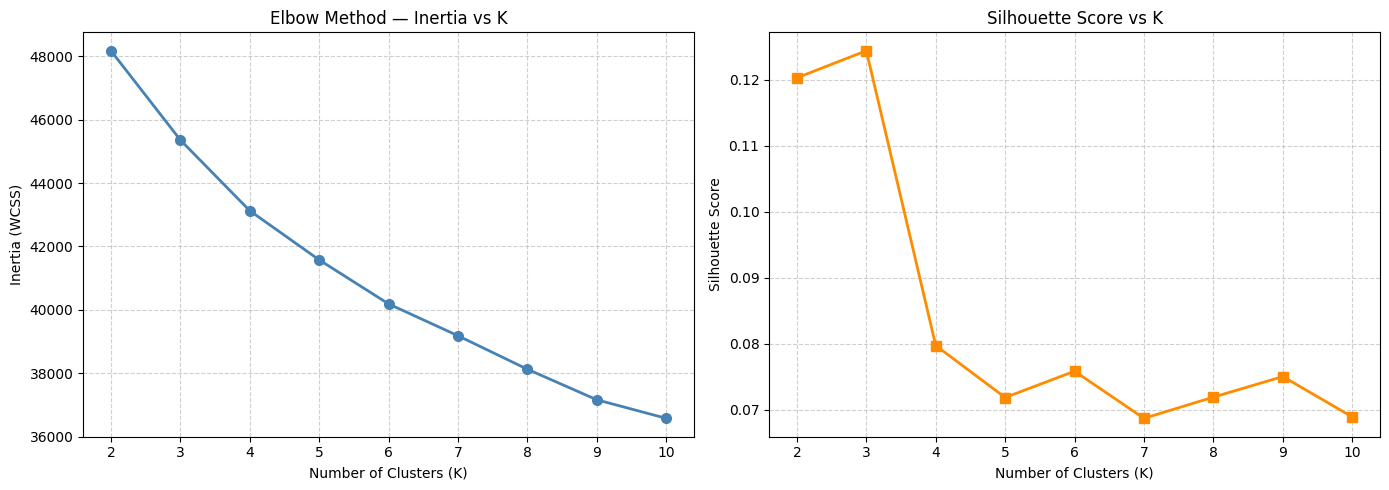


✅ Optimal K = 3 (highest silhouette score = 0.1244)


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertia, marker='o', color='steelblue', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, marker='s', color='darkorange', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
print(f'\n✅ Optimal K = {best_k} (highest silhouette score = {max(silhouette_scores):.4f})')

## Step 8: Train Final K-Means Model

In [28]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)
df['Cluster'] = kmeans_final.labels_

print(f'✅ K-Means trained with K = {best_k}')
print('\n=== Cluster Distribution ===')
print(df['Cluster'].value_counts().sort_index())

✅ K-Means trained with K = 3

=== Cluster Distribution ===
Cluster
0    1606
1     353
2     707
Name: count, dtype: int64


## Step 9: Visualize Clusters using PCA (2D Scatter Plot)

Explained variance by 2 components: 20.8%


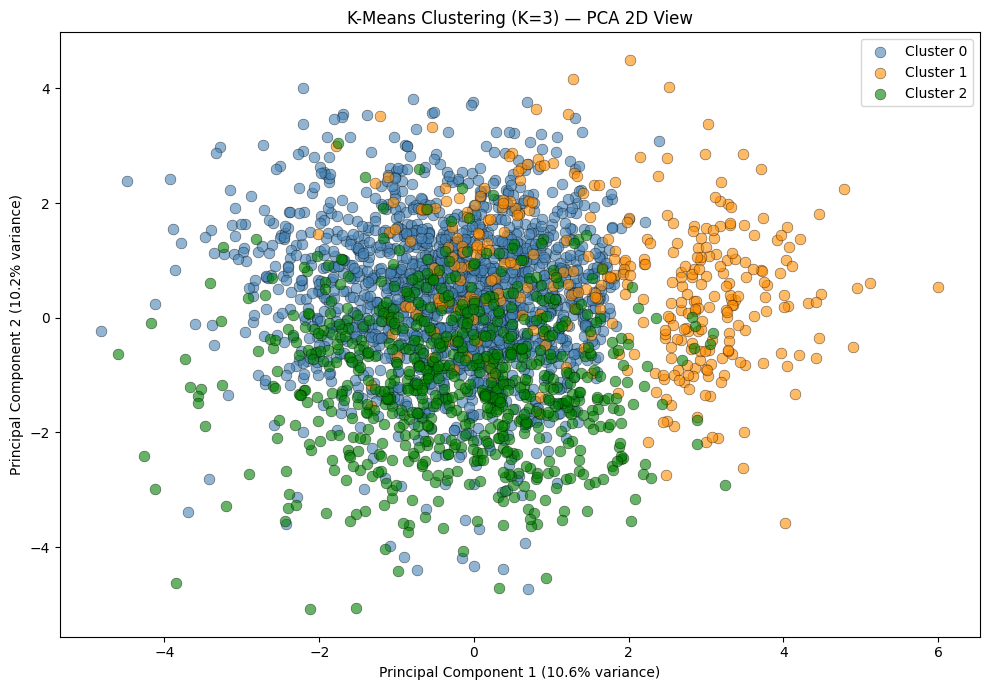

In [29]:
# Reduce to 2D using PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained variance by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%')

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = kmeans_final.labels_

# 2D Scatter plot
plt.figure(figsize=(10, 7))
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple', 'brown', 'pink']
for cluster in sorted(pca_df['Cluster'].unique()):
    subset = pca_df[pca_df['Cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'],
                label=f'Cluster {cluster}',
                color=colors[cluster % len(colors)],
                alpha=0.6, edgecolors='black', linewidths=0.4, s=60)

plt.title(f'K-Means Clustering (K={best_k}) — PCA 2D View')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.show()

## Step 10: Interpret Clustering Results

In [30]:
# Cluster profile — mean of each feature per cluster
cluster_profile = df.groupby('Cluster').mean().round(2)
print('=== Cluster Profiles (Mean Values per Cluster) ===')
print(cluster_profile.T)

=== Cluster Profiles (Mean Values per Cluster) ===
Cluster                      0       1       2
State                    26.20   26.20   25.59
Account length          100.05  103.51  100.47
Area code               437.27  437.82  437.63
International plan        0.06    0.37    0.07
Voice mail plan           0.00    0.07    1.00
Number vmail messages     0.00    2.06   29.22
Total day minutes       171.46  215.70  179.61
Total day calls         100.20  101.38  100.03
Total day charge         29.15   36.67   30.54
Total eve minutes       197.01  213.41  201.54
Total eve calls         100.06   99.73  100.10
Total eve charge         16.75   18.14   17.13
Total night minutes     199.70  207.10  201.54
Total night calls        99.90  100.62  100.32
Total night charge        8.99    9.32    9.07
Total intl minutes       10.15   10.96   10.07
Total intl calls          4.54    4.04    4.52
Total intl charge         2.74    2.96    2.72
Customer service calls    1.47    2.07    1.52
Churn    

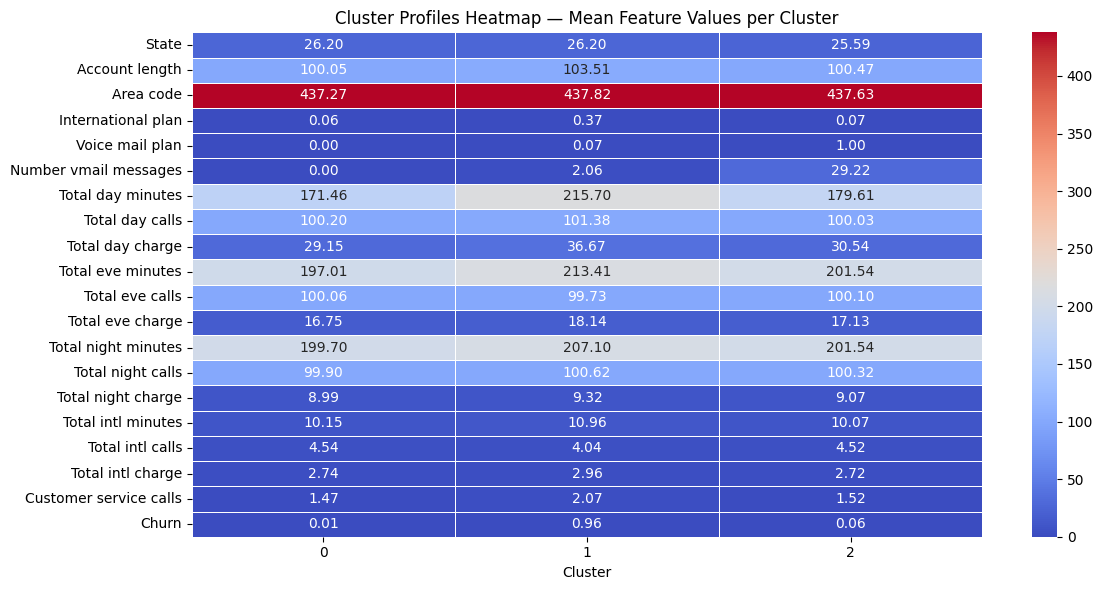


📌 Interpretation:
  Each row = a feature
  Each column = a cluster
  Red = high value, Blue = low value


In [31]:
# Heatmap of cluster profiles
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile.T, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Cluster Profiles Heatmap — Mean Feature Values per Cluster')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

print('\n📌 Interpretation:')
print('  Each row = a feature')
print('  Each column = a cluster')
print('  Red = high value, Blue = low value')


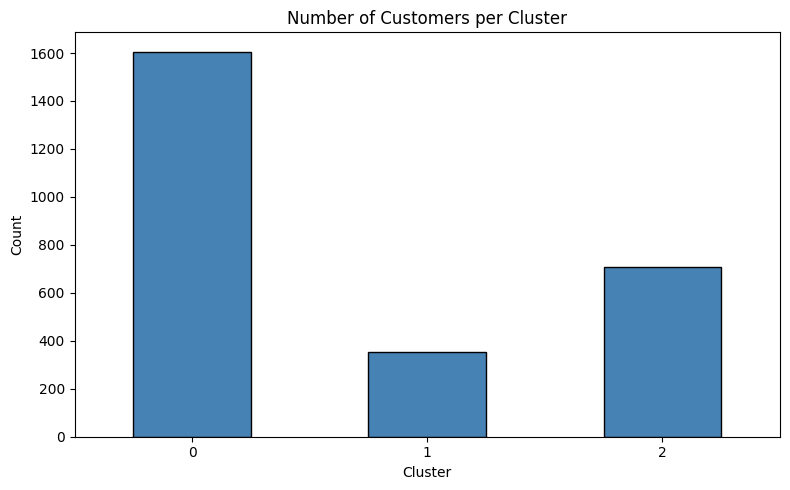

In [32]:
# Cluster size distribution
cluster_counts = df['Cluster'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()